LEVEL 1

=== TASK 1: DATA CLEANING & PREPROCESSING ===

Missing values per column:
Unnamed: 0.1    0
Text            0
Sentiment       0
Timestamp       0
User            0
Platform        0
Hashtags        0
Retweets        0
Likes           0
Country         0
Year            0
Month           0
Day             0
Hour            0
dtype: int64

Number of duplicate rows found: 0

=== TASK 2: EXPLORATORY DATA ANALYSIS (EDA) ===

--- Detailed Summary Statistics ---
            Likes    Retweets
count  732.000000  732.000000
mean    42.901639   21.508197
std     14.089848    7.061286
min     10.000000    5.000000
25%     34.750000   17.750000
50%     43.000000   22.000000
75%     50.000000   25.000000
max     80.000000   40.000000
Median Likes: 43.0
Median Retweets: 22.0
Mode Sentiment (Most Frequent): Positive
Mode Platform (Most Active): Instagram

--- Correlation Matrix ---
              Unnamed: 0.1  Retweets     Likes      Year     Month       Day  \
Unnamed: 0.1      1.000000  0.388637  0.3

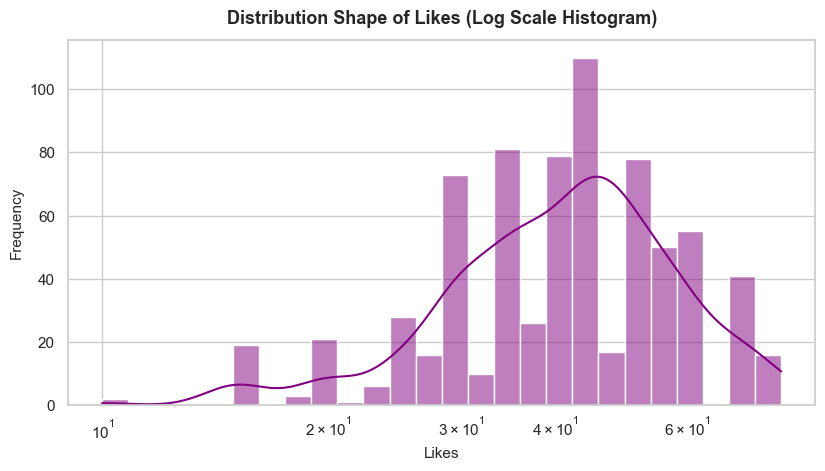

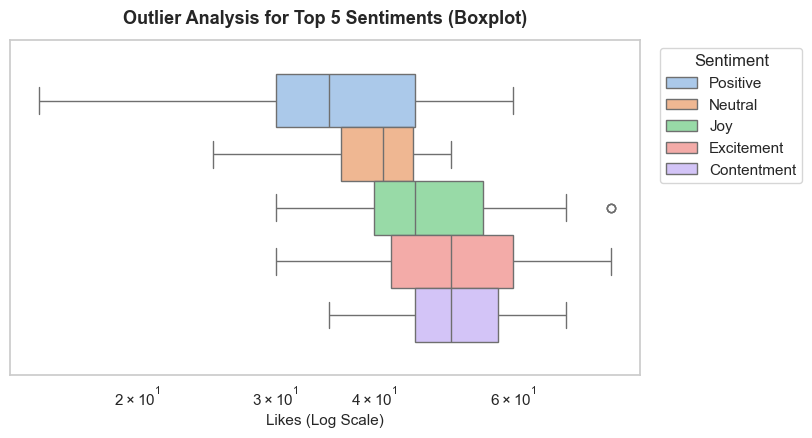


=== TASK 3: BASIC DATA VISUALIZATION ===


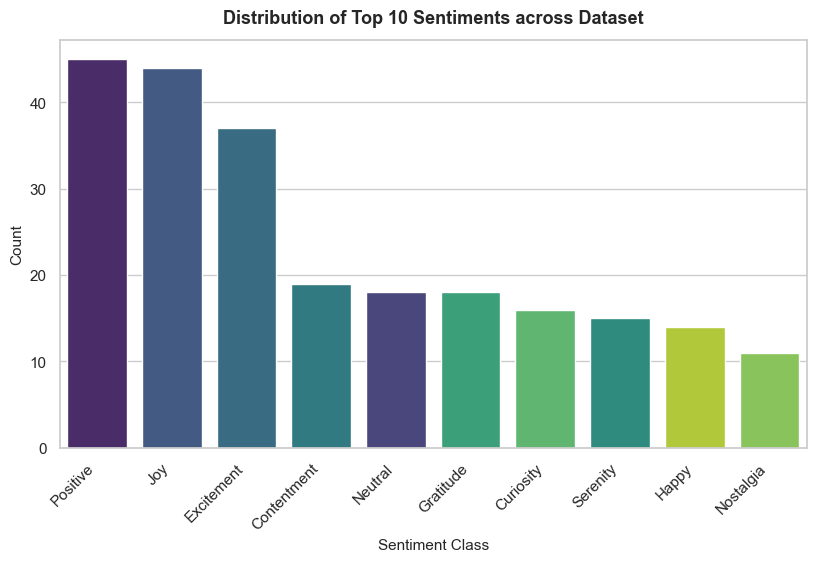

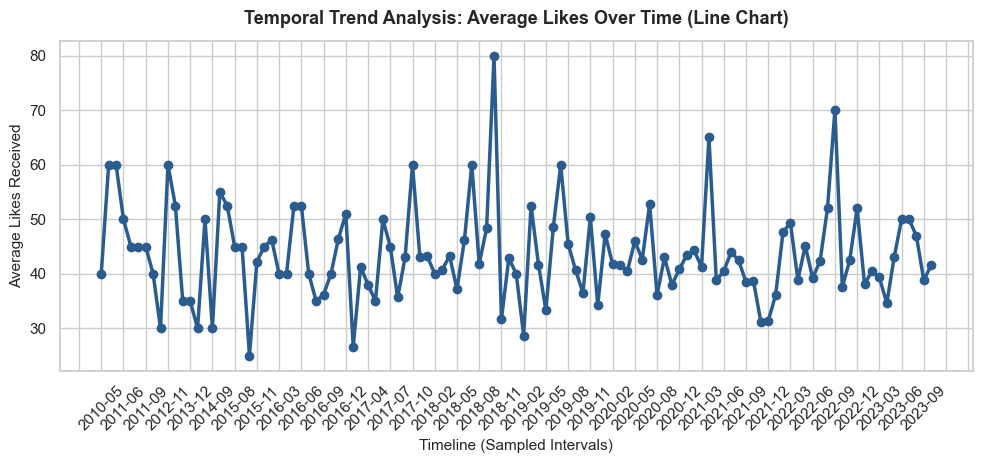

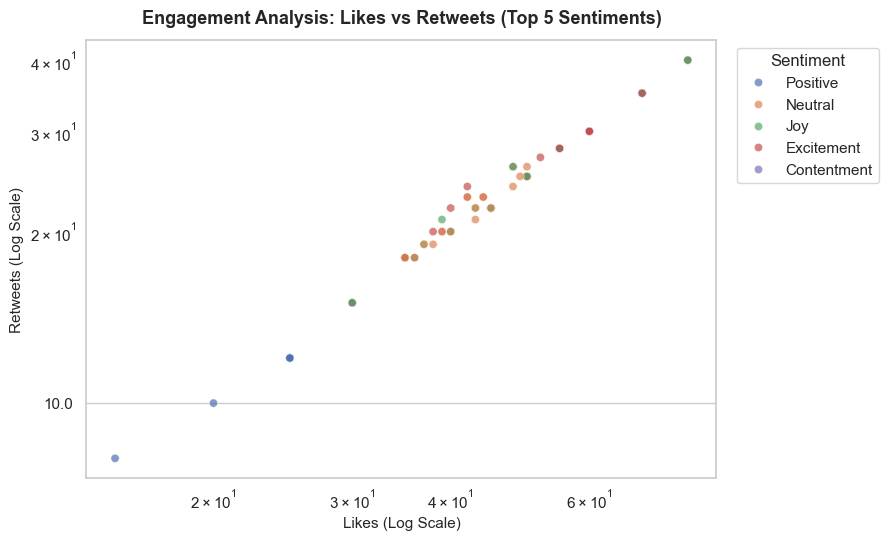

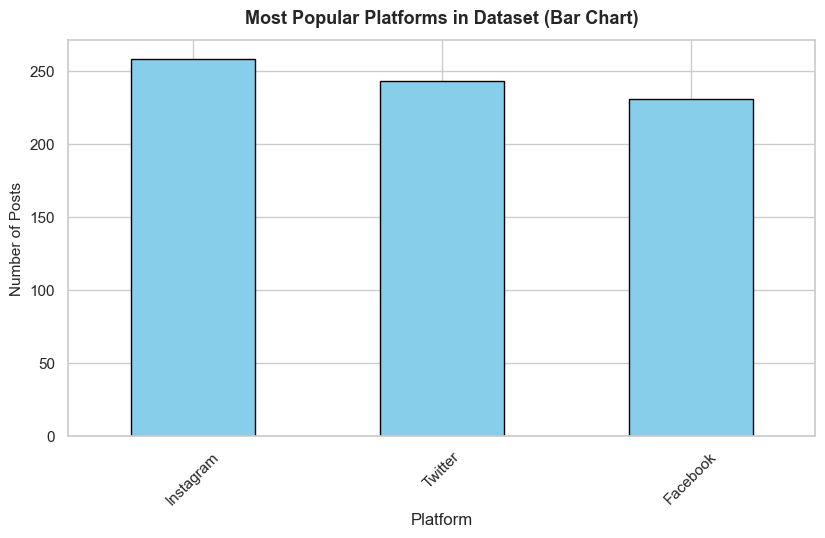

In [8]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.ticker as ticker

# Set clean default theme for plots
sns.set_theme(style="whitegrid")

# =====================================================================
# TASK 1: DATA CLEANING AND PREPROCESSING
# =====================================================================
print("=== TASK 1: DATA CLEANING & PREPROCESSING ===")

df = pd.read_csv(r"C:\Users\DELL\Downloads\3) Sentiment dataset.csv")

if 'Unnamed: 0' in df.columns:
    df = df.drop(columns=['Unnamed: 0'])

df.columns = df.columns.str.strip()

for col in ['Text', 'Sentiment', 'Platform', 'Country']:
    df[col] = df[col].astype(str).str.strip()

print("\nMissing values per column:")
print(df.isnull().sum())

duplicate_count = df.duplicated().sum()
print(f"\nNumber of duplicate rows found: {duplicate_count}")
if duplicate_count > 0:
    df = df.drop_duplicates()
    print("Duplicates removed successfully!")


# =====================================================================
# TASK 2: EXPLORATORY DATA ANALYSIS (EDA)
# =====================================================================
print("\n=== TASK 2: EXPLORATORY DATA ANALYSIS (EDA) ===")

print("\n--- Detailed Summary Statistics ---")
print(df[['Likes', 'Retweets']].describe())

print(f"Median Likes: {df['Likes'].median()}")
print(f"Median Retweets: {df['Retweets'].median()}")
print(f"Mode Sentiment (Most Frequent): {df['Sentiment'].mode()[0]}")
print(f"Mode Platform (Most Active): {df['Platform'].mode()[0]}")

print("\n--- Correlation Matrix ---")
numerical_df = df.select_dtypes(include=['number'])
correlation_matrix = numerical_df.corr()
print(correlation_matrix)

# New Histogram for checking distribution shape (Clean layout)
plt.figure(figsize=(9, 5))
sns.histplot(data=df, x='Likes', kde=True, color='purple', log_scale=True)
plt.title('Distribution Shape of Likes (Log Scale Histogram)', fontsize=13, fontweight='bold', pad=12)
plt.xlabel('Likes', fontsize=11)
plt.ylabel('Frequency', fontsize=11)
plt.subplots_adjust(bottom=0.15, top=0.88, left=0.12, right=0.95)
plt.show()

# --- SOLUTION 3 APPLIED HERE (Boxplot) ---
# Filter for Top 5 Sentiments so legend/plot doesn't break
top_5_sentiments = df['Sentiment'].value_counts().head(5).index
df_top_sentiments = df[df['Sentiment'].isin(top_5_sentiments)]

plt.figure(figsize=(10, 5))
ax = sns.boxplot(data=df_top_sentiments, x='Likes', hue='Sentiment', palette='pastel')
plt.xscale('log')
plt.gca().xaxis.set_major_formatter(ticker.ScalarFormatter())

# Position legend properly outside the frame
sns.move_legend(ax, "upper left", bbox_to_anchor=(1.02, 1))

plt.title('Outlier Analysis for Top 5 Sentiments (Boxplot)', fontsize=13, fontweight='bold', pad=12)
plt.xlabel('Likes (Log Scale)', fontsize=11)
# Note: right=0.75 gives space for the external legend
plt.subplots_adjust(bottom=0.18, top=0.85, left=0.12, right=0.75) 
plt.show()


# =====================================================================
# TASK 3: BASIC DATA VISUALIZATION
# =====================================================================
print("\n=== TASK 3: BASIC DATA VISUALIZATION ===")

# 1. Bar Plot: Sentiment Distribution (Top 10 to keep x-axis clean)
top_10_sentiments = df['Sentiment'].value_counts().head(10).index
df_top_10 = df[df['Sentiment'].isin(top_10_sentiments)]

plt.figure(figsize=(9, 6))
sns.countplot(
    data=df_top_10, 
    x='Sentiment', 
    hue='Sentiment',          
    palette='viridis', 
    order=top_10_sentiments,
    legend=False              
)
plt.title('Distribution of Top 10 Sentiments across Dataset', fontsize=13, fontweight='bold', pad=12)
plt.xlabel('Sentiment Class', fontsize=11)
plt.ylabel('Count', fontsize=11)
plt.xticks(rotation=45, ha='right')
plt.subplots_adjust(bottom=0.20, top=0.88, left=0.12, right=0.95)
plt.show()

# 2. Line Chart: Temporal Trend Analysis
monthly_trends = df.groupby(['Year', 'Month'])['Likes'].mean().reset_index()
monthly_trends['Period'] = monthly_trends['Year'].astype(str) + '-' + monthly_trends['Month'].astype(str).str.zfill(2)
monthly_trends = monthly_trends.sort_values('Period')

fig, ax = plt.subplots(figsize=(11, 5))
ax.plot(monthly_trends['Period'], monthly_trends['Likes'], marker='o', color='#2b5c8f', linewidth=2.5)
ax.xaxis.set_major_locator(ticker.MultipleLocator(3))

plt.title('Temporal Trend Analysis: Average Likes Over Time (Line Chart)', fontsize=13, fontweight='bold', pad=12)
plt.xlabel('Timeline (Sampled Intervals)', fontsize=11)
plt.ylabel('Average Likes Received', fontsize=11)
plt.xticks(rotation=45)
plt.subplots_adjust(bottom=0.22, top=0.88, left=0.12, right=0.95)
plt.show()

# 3. Scatter Plot: Engagement Correlation
# --- SOLUTION 3 APPLIED HERE (Scatter Plot) ---
plt.figure(figsize=(10, 6))
ax = sns.scatterplot(data=df_top_sentiments, x='Likes', y='Retweets', hue='Sentiment', palette='deep', alpha=0.7)
plt.xscale('log')
plt.yscale('log')

plt.gca().xaxis.set_major_formatter(ticker.ScalarFormatter())
plt.gca().yaxis.set_major_formatter(ticker.ScalarFormatter())

# Move legend outside the plot box
sns.move_legend(ax, "upper left", bbox_to_anchor=(1.02, 1))

plt.title('Engagement Analysis: Likes vs Retweets (Top 5 Sentiments)', fontsize=13, fontweight='bold', pad=12)
plt.xlabel('Likes (Log Scale)', fontsize=11)
plt.ylabel('Retweets (Log Scale)', fontsize=11)
plt.subplots_adjust(bottom=0.15, top=0.88, left=0.12, right=0.75)
plt.show()

# 4. Bar Plot: Top Platforms
plt.figure(figsize=(9, 6))
df['Platform'].value_counts().plot(kind='bar', color='skyblue', edgecolor='black')
plt.title('Most Popular Platforms in Dataset (Bar Chart)', fontsize=13, fontweight='bold', pad=12)
plt.ylabel('Number of Posts', fontsize=11)
plt.xticks(rotation=45)
plt.subplots_adjust(bottom=0.22, top=0.88, left=0.12, right=0.95)
plt.show()

LEVEL 2

=== LEVEL 2: TASK 1 - REGRESSION ANALYSIS ===
R-squared (R2) Score: 0.6688
Mean Squared Error (MSE): 24.2911


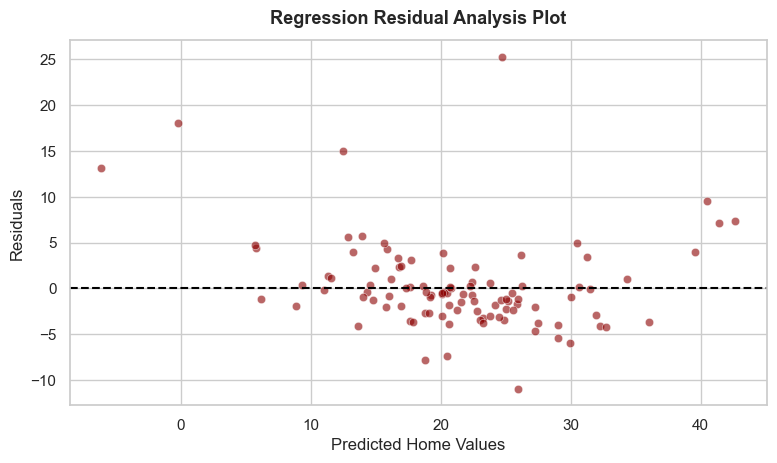

In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error

print("=== LEVEL 2: TASK 1 - REGRESSION ANALYSIS ===")

# 1. Load data using blank space separators
house_path = r"C:\Users\DELL\Downloads\4) house Prediction Data Set.csv"
column_names = ['CRIM', 'ZN', 'INDUS', 'CHAS', 'NOX', 'RM', 'AGE', 'DIS', 'RAD', 'TAX', 'PTRATIO', 'B', 'LSTAT', 'MEDV']

house_df = pd.read_csv(house_path, sep=r'\s+', names=column_names, engine='python')

# Target is MEDV (Median home value), predictors are all other columns
X = house_df.drop(columns=['MEDV'])
y = house_df['MEDV']

# 2. Train-Test Split (80% Train, 20% Test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 3. Model Fitting
reg_model = LinearRegression()
reg_model.fit(X_train, y_train)

# 4. Predictions & Evaluation Evaluation
y_pred = reg_model.predict(X_test)
r2 = r2_score(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)

print(f"R-squared (R2) Score: {r2:.4f}")
print(f"Mean Squared Error (MSE): {mse:.4f}")

# Plot Residuals
plt.figure(figsize=(9, 5))
sns.scatterplot(x=y_pred, y=(y_test - y_pred), alpha=0.6, color='darkred')
plt.axhline(y=0, color='black', linestyle='--')
plt.title('Regression Residual Analysis Plot', fontsize=13, fontweight='bold', pad=12)
plt.xlabel('Predicted Home Values')
plt.ylabel('Residuals')
plt.subplots_adjust(bottom=0.15, top=0.88)
plt.show()


=== LEVEL 2: TASK 2 - TIME SERIES ANALYSIS (DARK THEME) ===


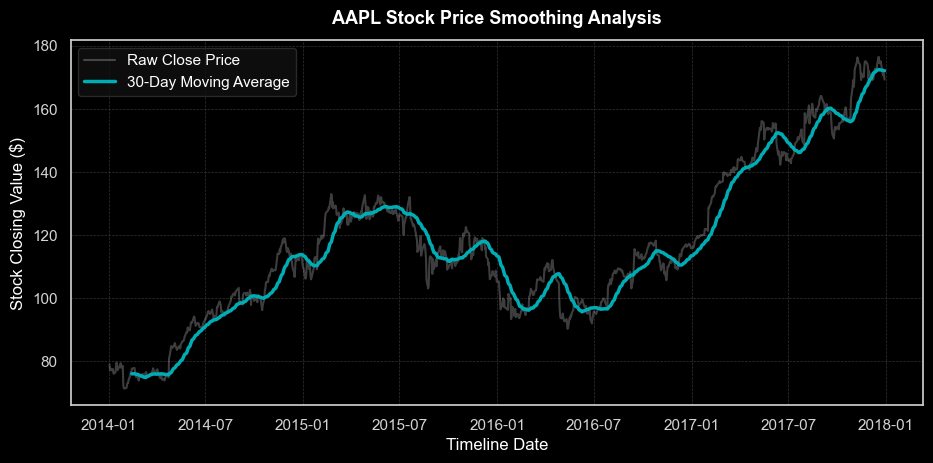

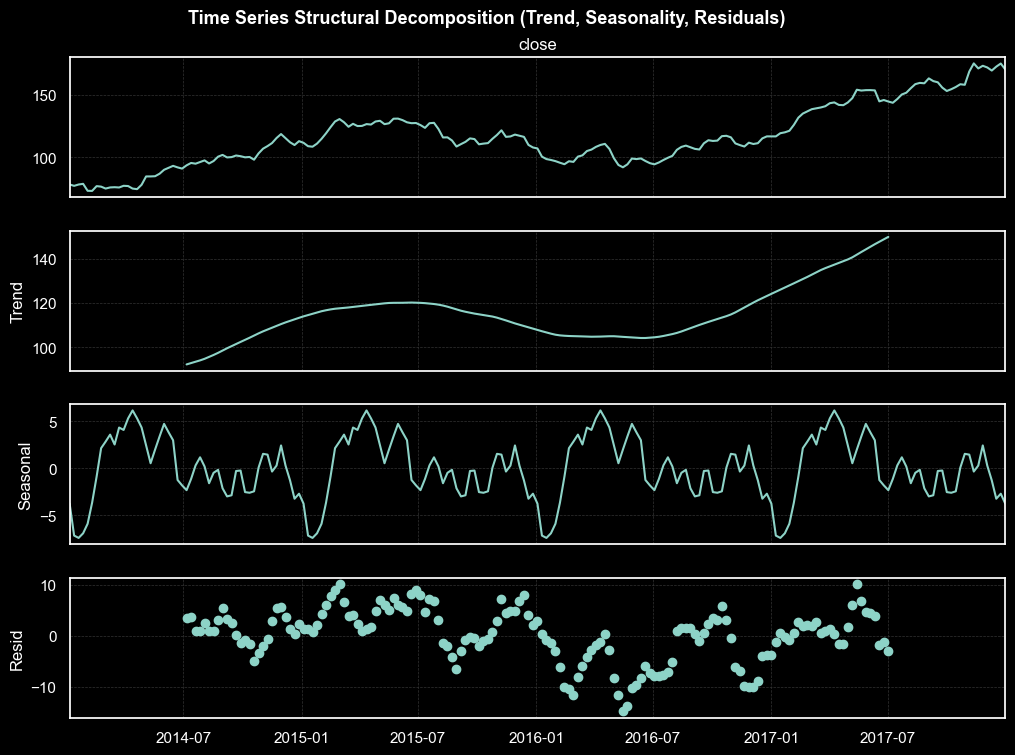

In [11]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from statsmodels.tsa.seasonal import seasonal_decompose

print("\n=== LEVEL 2: TASK 2 - TIME SERIES ANALYSIS (DARK THEME) ===")

# 1. Load and parse dates
stock_path = r"C:\Users\DELL\Downloads\2) Stock Prices Data Set.csv"
stock_df = pd.read_csv(stock_path, parse_dates=['date'])
stock_df.columns = stock_df.columns.str.strip()

# 2. Isolate a single stock ticker for meaningful time analysis
aapl_df = stock_df[stock_df['symbol'] == 'AAPL'].sort_values('date').copy()
aapl_df.set_index('date', inplace=True)

# Resample to weekly mean business days cleanly
aapl_weekly = aapl_df['close'].resample('W').mean().ffill()

# 3. Moving Average Smoothing
aapl_df['30D_Moving_Avg'] = aapl_df['close'].rolling(window=30).mean()


# --- CHART 1: AAPL SMOOTHING ANALYSIS (CUSTOM DARK CONFIGURATION) ---
# Set the figure facecolor to black
fig1, ax1 = plt.subplots(figsize=(11, 5), facecolor='black')

# Set the inner plot area (axes) background to black
ax1.set_facecolor('black')

# Plot lines using vibrant colors that pop against a dark background
ax1.plot(aapl_df.index, aapl_df['close'], label='Raw Close Price', alpha=0.3, color='#cccccc')
ax1.plot(aapl_df.index, aapl_df['30D_Moving_Avg'], label='30-Day Moving Average', color='#00adb5', linewidth=2.5)

# Configure titles and labels to white text
ax1.set_title('AAPL Stock Price Smoothing Analysis', fontsize=13, fontweight='bold', pad=12, color='white')
ax1.set_xlabel('Timeline Date', color='white')
ax1.set_ylabel('Stock Closing Value ($)', color='white')

# Adjust tick colors to light gray
ax1.tick_params(colors='lightgray', which='both')

# Style the grid lines softly so they do not overpower the visual lines
ax1.grid(True, color='#333333', linestyle='--', linewidth=0.5)

# Style the legend container for dark backgrounds
legend = ax1.legend(facecolor='#111111', edgecolor='#333333')
for text in legend.get_texts():
    text.set_color('white')

plt.subplots_adjust(bottom=0.15, top=0.88)
plt.show()


# --- CHART 2: TIME SERIES DECOMPOSITION (BUILT-IN DARK CONFIGURATION) ---
# Using context manager to apply 'dark_background' style ONLY to this plot
with plt.style.context('dark_background'):
    decomposition = seasonal_decompose(aapl_weekly, model='additive', period=52)
    
    # Generate the subplots using the styled properties
    fig2 = decomposition.plot()
    fig2.set_size_inches(11, 8)
    fig2.patch.set_facecolor('black') # Enforce strict pitch black outer canvas
    
    # Loop dynamically through generated subplots to force a matching pitch black background
    for ax in fig2.axes:
        ax.set_facecolor('black')
        ax.grid(True, color='#333333', linestyle='--', linewidth=0.5)
        
    plt.suptitle('Time Series Structural Decomposition (Trend, Seasonality, Residuals)', 
                 fontsize=13, fontweight='bold', y=0.98, color='white')
    plt.show()

LEVEL 3

In [13]:
import pandas as pd
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score

print("\n=== LEVEL 3: TASK 1 - CLASSIFICATION MODELING ===")

# 1. Load Data
iris_path = r"C:\Users\DELL\Downloads\1) iris.csv"
iris_df = pd.read_csv(iris_path)
iris_df.columns = iris_df.columns.str.strip()

# Features and target labels
X_iris = iris_df.drop(columns=['species'])
le = LabelEncoder()
y_iris = le.fit_transform(iris_df['species'])

# 2. Split and Scale
X_train, X_test, y_train, y_test = train_test_split(X_iris, y_iris, test_size=0.2, random_state=42)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 3. Random Forest Classification with Hyperparameter Grid Search Optimization
rf_base = RandomForestClassifier(random_state=42)
param_grid = {
    'n_estimators': [10, 50, 100],
    'max_depth': [None, 3, 5]
}

grid_clf = GridSearchCV(estimator=rf_base, param_grid=param_grid, cv=3, scoring='accuracy')
grid_clf.fit(X_train_scaled, y_train)

# 4. Predictions and Final Performance Report
best_model = grid_clf.best_estimator_
predictions = best_model.predict(X_test_scaled)

print(f"Optimized Parameters: {grid_clf.best_params_}")
print(f"Model Assessment Accuracy Score: {accuracy_score(y_test, predictions):.4f}\n")
print(classification_report(y_test, predictions, target_names=le.classes_))


=== LEVEL 3: TASK 1 - CLASSIFICATION MODELING ===
Optimized Parameters: {'max_depth': 3, 'n_estimators': 10}
Model Assessment Accuracy Score: 1.0000

              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       1.00      1.00      1.00         9
   virginica       1.00      1.00      1.00        11

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30



In [14]:
!pip install textblob wordcloud


=== LEVEL 3: TASK 3 - NLP SENTIMENT ANALYSIS ===
Calculated Text Metrics Sample:
                                                Text  Polarity_Score
0   Enjoying a beautiful day at the park!        ...        0.675000
1   Traffic was terrible this morning.           ...       -1.000000
2   Just finished an amazing workout! 💪          ...        0.600000
3   Excited about the upcoming weekend getaway!  ...        0.375000
4   Trying out a new recipe for dinner tonight.  ...        0.136364


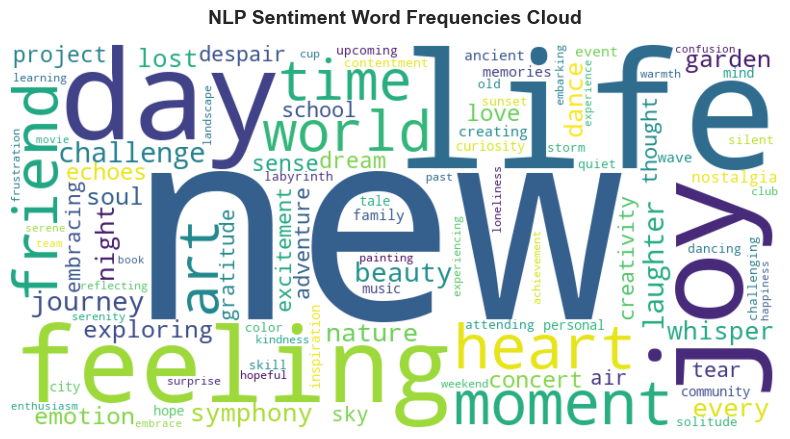

In [15]:
import pandas as pd
import matplotlib.pyplot as plt
from textblob import TextBlob
from wordcloud import WordCloud, STOPWORDS

print("\n=== LEVEL 3: TASK 3 - NLP SENTIMENT ANALYSIS ===")

# 1. Load data and clean spacing strings
sentiment_path = r"C:\Users\DELL\Downloads\3) Sentiment dataset.csv"
nlp_df = pd.read_csv(sentiment_path)
nlp_df.columns = nlp_df.columns.str.strip()

def preprocess_text(text):
    text = str(text).lower()
    for char in ['.', ',', '!', '?', '"', "'", '(', ')', '#', '💪']:
        text = text.replace(char, '')
    return text.strip()

nlp_df['Cleaned_Text'] = nlp_df['Text'].apply(preprocess_text)

# 2. Polarity score mapping via TextBlob engines
nlp_df['Polarity_Score'] = nlp_df['Cleaned_Text'].apply(lambda x: TextBlob(x).sentiment.polarity)

print("Calculated Text Metrics Sample:")
print(nlp_df[['Text', 'Polarity_Score']].head())

# 3. Generate Word Cloud Visual Distribution
all_words_combined = " ".join(review for review in nlp_df['Cleaned_Text'])
custom_stopwords = set(STOPWORDS)

wordcloud = WordCloud(
    width=800, 
    height=400, 
    background_color='white', 
    stopwords=custom_stopwords, 
    colormap='viridis',
    max_words=100
).generate(all_words_combined)

# Plot Visual Cloud Output
plt.figure(figsize=(10, 5))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')  
plt.title('NLP Sentiment Word Frequencies Cloud', fontsize=14, fontweight='bold', pad=15)
plt.show()